# Семинар 8

План семинара – Последовательное тестирование
- проблема подглядывания
- likelihood ratio
- SPRT Вальда
- Примеры
- Применение на практике
- Почему последовательное тестирование ускоряет эксперименты

# 1. Проблема подглядывания (peek-testing)

В классическом A/B-тесте уровень значимости \alpha контролируется только при одном фиксированном тесте.
Если же мы начинаем проверять гипотезу много раз по мере накопления данных, вероятность ложного обнаружения эффекта резко возрастает.

Представим эксперимент:
- $H_0$: эффекта нет
- $H_1$: есть эффект на уровне значимости \alpha = 0.05

Если мы проводим один тест, вероятность ложного срабатывания:

$P(\text{Type I error}) = 0.05$

Но если после каждого нового наблюдения пересчитывать статистику и останавливаться при первом значимом результате, мы **фактически проводим много тестов**. Каждая проверка — это шанс **случайно** получить p < 0.05.

Просимулируем – 1000 раз проведем эксперимент с подглядыванием, то есть будем останавливаться на первом прокрасе. 
- одинаковые распределения размера 200
- ожидаемый FPR - 5%, то есть 50 экспериментов могут быть ложно прокрашены


In [1]:
import numpy as np
from scipy.stats import ttest_ind, norm
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
false_positives = 0
experiments = 1000

for _ in range(experiments):

    control = []
    test = []

    for i in range(200):
        control.append(np.random.normal())
        test.append(np.random.normal())

        if i > 20:  # начинаем проверять после небольшого n
            _, p = ttest_ind(control, test)

            if p < 0.05:
                false_positives += 1
                break

false_positives / experiments

0.297

У нас же прокрасилось почти 300 экспериментов из 1000 вместо 50! Ред флаг о том, что наша постановка эксперимента некорректна, не соблюдается О1Р

Итого:

Проблема peek testing в том, что:
- p-value контролирует ошибку только при одной проверке
- многократные проверки разрушают контроль ошибки I рода

Существует отдельный вид экспериментов, дизайн которого "позволяет" подглядывать в ход эксперимента – последовательное тестирование.

# 2. Идея likelihood ratio

Идея последовательного тестирования основана на сравнении того, **насколько наблюдаемые данные вероятны при разных гипотезах**.

Пусть есть две гипотезы:

- $H_0$ — эффекта нет  
- $H_1$ — эффект есть  

Когда мы наблюдаем данные $x_1, x_2, ..., x_n$, можно вычислить их правдоподобие при каждой гипотезе:

$P(data \mid H_0)$  
$P(data \mid H_1)$

Для начала – напоминание про функции правдоподобий

Правдоподобие — это мера того, насколько **наблюдаемые** данные согласуются с гипотезой. 
  - Вероятность: Если параметр равен $\theta$, какие данные мы получим?
  - Правдоподобие: Если мы уже увидели данные ($x_1, x_2, ..., x_n$), какие параметры лучше всего их объясняют? Обычно функцию правдоподобия обозначают как $L(\theta) = P(x_1, x_2, ..., x_n \mid \theta)$

В последовательном тестировании **вместо p value** мы будем вычислять отношение правдоподобий:

$\Lambda_n = \frac{P(data \mid H_1)}{P(data \mid H_0)}$

Это называется **likelihood ratio**.

Интерпретация:

- если $\Lambda_n > 1$, данные более вероятны при $H_1$
- если $\Lambda_n < 1$, данные более вероятны при $H_0$

По мере поступления новых наблюдений это отношение **обновляется**.

Чтобы лучше осознать, как работает функция правдоподобия, смоделируем эксперимент с подбрасыванием монетки. Будем использовать вероятность орла отличную от 50%, на примерах ниже мы увидим, что такой тест быстрее сойдется.

In [3]:
# гипотезы
p0 = 0.5  # H0
p1 = 0.7  # H1

# сгенерируем наблюдения (1 = орел, 0 = решка)
data = np.random.binomial(1, 0.7, size=20)

lr = 1

for i, x in enumerate(data, 1):

    # вероятность наблюдения при каждой гипотезе
    p_x_h0 = p0 if x == 1 else (1 - p0)
    p_x_h1 = p1 if x == 1 else (1 - p1)

    lr *= p_x_h1 / p_x_h0

    print(f"n={i}, observation={x}, likelihood_ratio={lr:.3f}")

n=1, observation=1, likelihood_ratio=1.400
n=2, observation=0, likelihood_ratio=0.840
n=3, observation=1, likelihood_ratio=1.176
n=4, observation=1, likelihood_ratio=1.646
n=5, observation=1, likelihood_ratio=2.305
n=6, observation=0, likelihood_ratio=1.383
n=7, observation=1, likelihood_ratio=1.936
n=8, observation=0, likelihood_ratio=1.162
n=9, observation=1, likelihood_ratio=1.626
n=10, observation=1, likelihood_ratio=2.277
n=11, observation=1, likelihood_ratio=3.188
n=12, observation=1, likelihood_ratio=4.463
n=13, observation=1, likelihood_ratio=6.248
n=14, observation=1, likelihood_ratio=8.747
n=15, observation=1, likelihood_ratio=12.246
n=16, observation=1, likelihood_ratio=17.144
n=17, observation=0, likelihood_ratio=10.287
n=18, observation=0, likelihood_ratio=6.172
n=19, observation=1, likelihood_ratio=8.641
n=20, observation=1, likelihood_ratio=12.097


Если наблюдения независимы, правдоподобие разлагается в произведение:

$\Lambda_n = \prod_{i=1}^{n} P(x_i \mid H_1) / P(x_i \mid H_0)$

То есть **каждое новое наблюдение добавляет вклад в доказательство одной из гипотез**.

На практике удобнее работать с логарифмом likelihood ratio:

$S_n = \log(\Lambda_n)$

Тогда произведение превращается в сумму:

$S_n = \sum_{i=1}^{n} \log \left( P(x_i \mid H_1) / P(x_i \mid H_0) \right)$

Таким образом, последовательный тест можно интерпретировать как **накопление доказательств**:

- каждое наблюдение добавляет небольшой вклад
- сумма постепенно растёт или уменьшается
- когда доказательств становится достаточно, тест останавливается.

# 3. SPRT — Sequential Probability Ratio Test (тест Вальда)

Sequential Probability Ratio Test (SPRT) — это последовательный тест, предложенный Абрахамом Вальдом.  
Его идея — **наблюдать данные по мере поступления и останавливать эксперимент, как только накопилось достаточно доказательств** в пользу одной из гипотез

## Границы эксперимента
SPRT использует **две границы**, которые зависят от допустимых ошибок:

- $\alpha$ — вероятность ошибки I рода  
- $\beta$ — вероятность ошибки II рода

Границы:

$A = (1 - \beta) / \alpha$

$B = \beta / (1 - \alpha)$

## Правило остановки

После каждого нового наблюдения пересчитывается $\Lambda_n$.

Дальше возможны три ситуации:

| значение $\Lambda_n$ | решение |
|---|---|
| $\Lambda_n \ge A$ | принимаем $H_1$ |
| $\Lambda_n \le B$ | принимаем $H_0$ |
| $B < \Lambda_n < A$ | продолжаем эксперимент |

То есть эксперимент **останавливается, как только накопленные данные достаточно сильно поддерживают одну из гипотез**.

## Логарифм отношения правдоподобий

На практике удобнее использовать логарифм:

$S_n = \log(\Lambda_n)$

Тогда произведение превращается в сумму:

$S_n = \sum \log(P(x_i | H_1) / P(x_i | H_0))$

Каждое новое наблюдение **добавляет вклад в накопленное доказательство**.

## Интуитивная интерпретация

Можно представить последовательный тест как **накопление доказательств**:

- каждое наблюдение немного поддерживает $H_0$ или $H_1$
- статистика постепенно растёт или уменьшается
- когда она пересекает одну из границ — эксперимент останавливается.

# 4. Примеры

## Одна симуляция – биномиальное распределение

Просимулируем эксперимент с монеткой еще раз, только увеличим число подбрасываний монетки до 100. На каждой итерации будем вычислять логарифм отношения правдоподобий и сравнивать, не вышли ли мы за границы.

Будем использовать вероятность орла отличную от 50%, в моем примере 70%. Вы можете самостоятельно поменять значение параметра и посмотреть, как меняется скорость сходимости теста

n=20, observation=1, likelihood_ratio=1.400, log_lr=0.336
n=20, observation=1, likelihood_ratio=1.400, log_lr=0.673
n=20, observation=1, likelihood_ratio=1.400, log_lr=1.009
n=20, observation=1, likelihood_ratio=1.400, log_lr=1.346
n=20, observation=1, likelihood_ratio=1.400, log_lr=1.682
n=20, observation=1, likelihood_ratio=1.400, log_lr=2.019
n=20, observation=1, likelihood_ratio=1.400, log_lr=2.355
n=20, observation=0, likelihood_ratio=0.600, log_lr=1.844
n=20, observation=1, likelihood_ratio=1.400, log_lr=2.181
n=20, observation=0, likelihood_ratio=0.600, log_lr=1.670
n=20, observation=0, likelihood_ratio=0.600, log_lr=1.159
n=20, observation=1, likelihood_ratio=1.400, log_lr=1.496
n=20, observation=1, likelihood_ratio=1.400, log_lr=1.832
n=20, observation=0, likelihood_ratio=0.600, log_lr=1.321
n=20, observation=0, likelihood_ratio=0.600, log_lr=0.811
n=20, observation=1, likelihood_ratio=1.400, log_lr=1.147
n=20, observation=1, likelihood_ratio=1.400, log_lr=1.484
n=20, observat

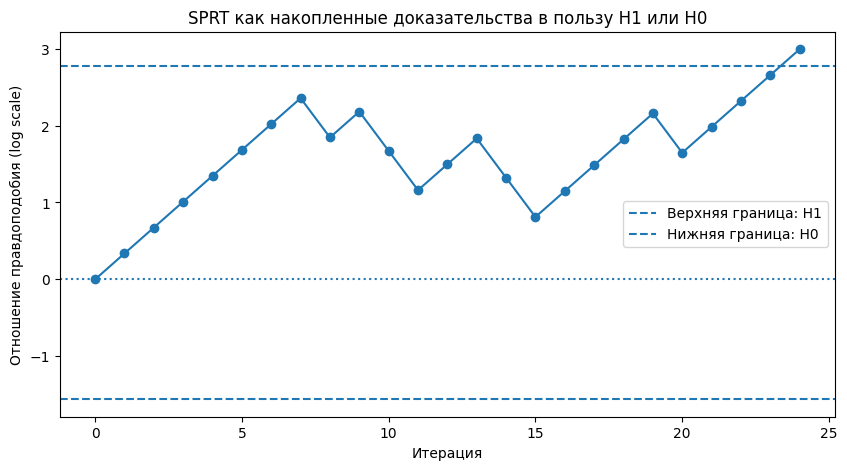

In [4]:
# ошибки
alpha = 0.05
beta = 0.2

# границы Вальда в лог-шкале
upper = np.log((1 - beta) / alpha)
lower = np.log(beta / (1 - alpha))

# генерируем с вероятностью 0.7, чтобы увидеть, как SPRT накапливает доказательства в пользу H1
data = np.random.binomial(1, 0.7, size=100)

log_lr_values = [0]
current_loglr = 0

for x in data:
    p_x_h0 = p0 if x == 1 else (1 - p0)
    p_x_h1 = p1 if x == 1 else (1 - p1)

    current_lr = p_x_h1 / p_x_h0
    current_loglr += np.log(current_lr)
    print(
        f"n={i}, observation={x}, likelihood_ratio={current_lr:.3f}, log_lr={current_loglr:.3f}"
    )
    log_lr_values.append(current_loglr)

    if current_loglr >= upper or current_loglr <= lower:
        break

plt.figure(figsize=(10, 5))
plt.plot(log_lr_values, marker="o")
plt.axhline(upper, linestyle="--", label="Верхняя граница: H1")
plt.axhline(lower, linestyle="--", label="Нижняя граница: H0")
plt.axhline(0, linestyle=":")
plt.xlabel("Итерация")
plt.ylabel("Отношение правдоподобия (log scale)")
plt.title("SPRT как накопленные доказательства в пользу H1 или H0")
plt.legend()
plt.show()

## Симуляция random walk 

В последовательном тесте статистика

$S_n = \log(\Lambda_n)$

обновляется после каждого наблюдения:

$S_n = S_{n-1} + \log(P(x_n | H_1) / P(x_n | H_0))$

Это означает, что каждая новая точка данных **добавляет небольшой шаг вверх или вниз**.  
Поэтому поведение статистики можно рассматривать как **random walk (случайное блуждание)**.

- если данные больше соответствуют $H_1$ → шаг чаще вверх  
- если данные больше соответствуют $H_0$ → шаг чаще вниз  

Эксперимент продолжается, пока траектория не пересечёт одну из границ.

Посмотрим, как выглядят random walk траектории для разных экспериментов.

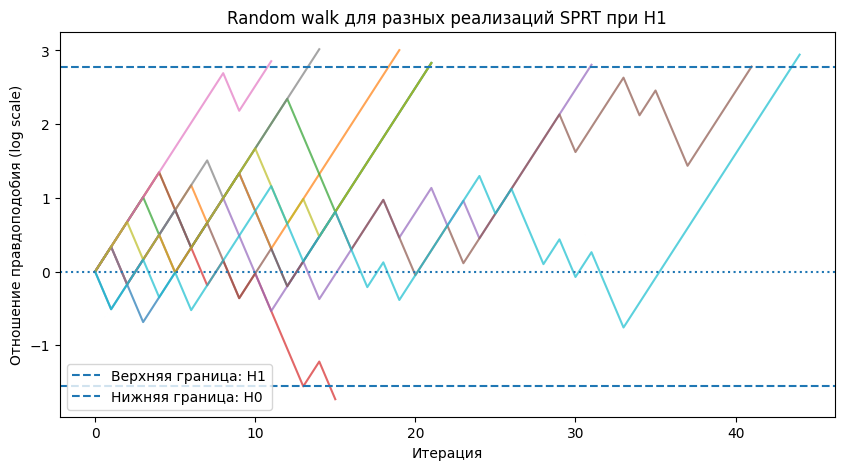

In [5]:
# параметры гипотез
p0 = 0.5
p1 = 0.7

alpha = 0.05
beta = 0.2

upper = np.log((1 - beta) / alpha)
lower = np.log(beta / (1 - alpha))


def simulate_walk(p_true, max_steps=200):
    data = np.random.binomial(1, p_true, size=max_steps)

    s = 0
    path = [s]

    for x in data:
        p_x_h0 = p0 if x == 1 else (1 - p0)
        p_x_h1 = p1 if x == 1 else (1 - p1)

        s += np.log(p_x_h1 / p_x_h0)
        path.append(s)

        if s >= upper or s <= lower:
            break

    return path


plt.figure(figsize=(10, 5))

for _ in range(10):
    path = simulate_walk(p_true=0.7)
    plt.plot(path, alpha=0.7)

plt.axhline(upper, linestyle="--", label="Верхняя граница: H1")
plt.axhline(lower, linestyle="--", label="Нижняя граница: H0")
plt.axhline(0, linestyle=":")

plt.xlabel("Итерация")
plt.ylabel("Отношение правдоподобия (log scale)")
plt.title("Random walk для разных реализаций SPRT при H1")
plt.legend()

plt.show()

- некоторые эксперименты **быстро достигают верхней границы**
- некоторые идут **дольше**
- если данные больше похожи на $H_0$, траектория может уйти вниз

Это показывает ключевую особенность последовательных тестов:

**размер выборки не фиксирован заранее — тест останавливается тогда, когда накопилось достаточно доказательств.**

# 5. Применение на практике – mSPRT

В примере с монеткой мы знали точную модель данных:

- $H_0$: $p = 0.5$
- $H_1$: $p = 0.7$

Поэтому можно было легко вычислить вклад каждого наблюдения.
Каждый новый бросок монеты добавлял небольшой вклад в **отношение правдоподобий**.

## Что меняется в реальном эксперименте

На самом первом семинаре мы обсуждали важную идею:  
*картина без эффекта* всегда описывается нулевой гипотезой, так как альтернативных вариантов может быть бесконечно много, и мы просто не знаем как ее сформулировать.

Здесь возникает та же проблема.  
В классическом SPRT альтернативная гипотеза должна быть **точечной**:

$$
H_1: \delta = \delta_1
$$

Но в реальном A/B-тесте мы почти никогда не знаем точный размер эффекта заранее.  
Обычно гипотеза выглядит так:

$$
H_1: \delta > 0
$$

То есть возможных эффектов бесконечно много. 
> Получается, классический SPRT возможно применять только в случаях, когда у нас есть основания задать определенный ожидаемый эффект. Сложно придумать такую ситуацию в реальности


## Первая идея — проверить несколько эффектов

Можно попробовать обойти эту проблему, проверяя несколько возможных эффектов.

Например:

- тестируем ARPU
- в A/A тестах $ARPU_{test} = ARPU_{control} = 1000$
- предположим возможные эффекты: 1%, 2%, 3%

Тогда можно запустить несколько SPRT одновременно:

$$
H_{1,1}: \delta = 1%
$$

$$
H_{1,2}: \delta = 2%
$$

$$
H_{1,3}: \delta = 3%
$$

И наблюдать за тем, пересечёт ли какой-то из тестов свою границу.

Но если просто остановиться, когда **любой** из них примет $H_1$,  
мы столкнёмся с проблемой множественного тестирования — вероятность ошибки первого рода увеличится.

## Переход к mSPRT

Идея проверять несколько возможных эффектов на самом деле очень естественная.  
Если обобщить её, можно рассмотреть **все возможные эффекты одновременно**.

Вместо одной альтернативы

$$
H_1: \delta = \delta_1
$$

или конечного набора эффектов {1%, 2%, 3%}

мы рассматриваем **распределение возможных эффектов**

$$
\delta \sim g(\delta)
$$

Тогда отношение правдоподобий считается не для одного эффекта, а как **смесь по всем возможным эффектам**.

В общем виде likelihood ratio для mSPRT записывается так:

$$
\Lambda_n =
\int
\frac{P(X_1,\dots,X_n \mid \delta)}
     {P(X_1,\dots,X_n \mid \delta = 0)}
\, g(\delta)\, d\delta
$$
где

- $P(X_1,\dots,X_n \mid \delta)$ — правдоподобие данных при эффекте $\delta$  
- $g(\delta)$ — распределение возможных эффектов (prior на альтернативу)

Числитель можно интерпретировать как **усреднённое правдоподобие данных по всем возможным эффектам**.

Этот подход называется **mixture Sequential Probability Ratio Test (mSPRT)**.

Главная идея при этом остаётся той же:

> каждое новое наблюдение **добавляет небольшое доказательство** в пользу одной из альтернативных гипотез

## Как выбирается граница остановки

Чтобы понять, когда нужно остановить тест, используется важное свойство likelihood ratio.

Если нулевая гипотеза верна, то последовательность $\Lambda_n$ обладает свойством мартингала и выполняется следующее неравенство:

$$
P_{H_0}\left(\sup_n \Lambda_n \ge \frac{1}{\alpha}\right) \le \alpha
$$

Это означает, что если $H_0$ верна, то вероятность того, что отношение правдоподобий **когда-либо** превысит $1/\alpha$, не больше уровня значимости $\alpha$ — даже если мы проверяем тест после каждого нового наблюдения.

Поэтому правило остановки в mSPRT выбирают очень простым:

$$
\Lambda_n \ge \frac{1}{\alpha}
$$

Если это условие выполняется, мы отклоняем $H_0$.

Например, при уровне значимости $\alpha = 0.05$ граница будет

$$
\Lambda_n \ge 20
$$

Интуитивно это означает, что данные стали **как минимум в 20 раз более вероятны при альтернативе, чем при нулевой гипотезе**, что считается достаточным доказательством против $H_0$.

[Классная статья про применение методов последовательного тестирования от Т-Банка](https://habr.com/ru/companies/tbank/articles/876984/)

Приведем простую симуляцию для примера с двумя нормальными распределениями и с набором потенциальных эффектов (наше распределение mixture для этого примера будет дискретным)

Stop at n=222, likelihood ratio=21.734


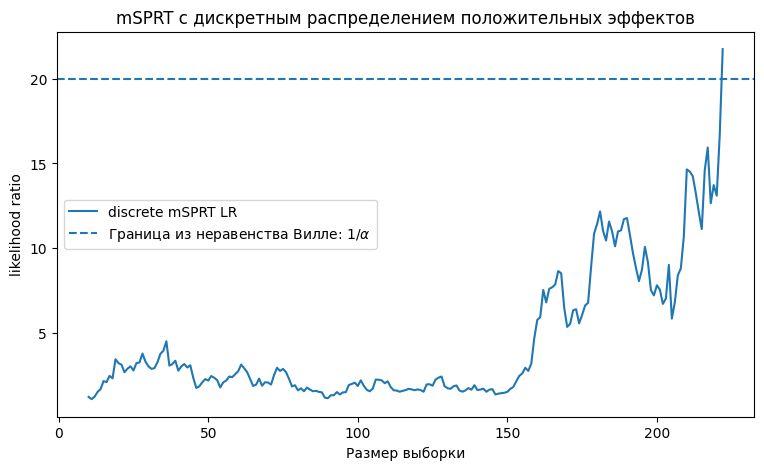

In [6]:
# симуляция данных
n = 1000
sigma = 1.0
true_effect = 0.2

control = np.random.normal(0, sigma, n)
test = np.random.normal(true_effect, sigma, n)

# уровень значимости и граница
alpha = 0.05
boundary = 1 / alpha

# дискретный набор возможных эффектов
deltas = np.array([0.05, 0.10, 0.15, 0.20, 0.25])
weights = np.ones(len(deltas)) / len(deltas)

lr_values_disc = []

for i in range(10, n + 1):
    c = control[:i]
    t = test[:i]

    diff = np.mean(t) - np.mean(c)

    # предполагаем известную дисперсию
    se = np.sqrt(sigma**2 / i + sigma**2 / i)

    # likelihood under H0
    lh0 = norm.pdf(diff, loc=0, scale=se)

    # смесь правдоподобия под h1 - наш интеграл по дискретному распределению эффектов
    lh1 = np.sum(weights * norm.pdf(diff, loc=deltas, scale=se))

    lr = lh1 / lh0
    lr_values_disc.append(lr)

    if lr >= boundary:
        print(f"Stop at n={i}, likelihood ratio={lr:.3f}")
        break

plt.figure(figsize=(9, 5))
plt.plot(range(10, 10 + len(lr_values_disc)), lr_values_disc, label="discrete mSPRT LR")
plt.axhline(boundary, linestyle="--", label="Граница из неравенства Вилле: $1/\\alpha$")
plt.xlabel("Размер выборки")
plt.ylabel("likelihood ratio")
plt.title("mSPRT с дискретным распределением положительных эффектов")
plt.legend()
plt.show()

Теперь то же самое, только на непрерывном распределении эффектов.

Stop at n=458, likelihood ratio=20.334


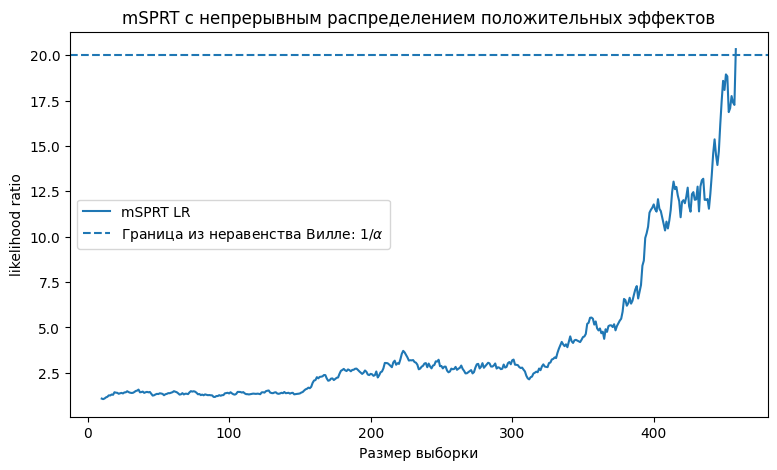

In [7]:
# one-sided prior: только положительные эффекты
tau = 0.05
delta_grid = np.linspace(0.0001, 0.25, 400)
prior = norm.pdf(delta_grid, loc=0, scale=tau)
prior = prior / prior.sum()

lr_values_cont = []

for i in range(10, n + 1):
    c = control[:i]
    t = test[:i]

    diff = np.mean(t) - np.mean(c)

    # предполагаем известную дисперсию
    se = np.sqrt(sigma**2 / i + sigma**2 / i)

    # правдоподобие при h0
    lh0 = norm.pdf(diff, loc=0, scale=se)

    # смесь правдоподобия под h1 - наш интеграл
    lh1 = np.sum(norm.pdf(diff, loc=delta_grid, scale=se) * prior)

    lr = lh1 / lh0
    lr_values_cont.append(lr)
    if lr >= boundary:
        print(f"Stop at n={i}, likelihood ratio={lr:.3f}")
        break

plt.figure(figsize=(9, 5))
plt.plot(
    list(range(10, n + 1))[: len(lr_values_cont)], lr_values_cont, label="mSPRT LR"
)
plt.axhline(boundary, linestyle="--", label="Граница из неравенства Вилле: $1/\\alpha$")
plt.xlabel("Размер выборки")
plt.ylabel("likelihood ratio")
plt.title("mSPRT с непрерывным распределением положительных эффектов")
plt.legend()
plt.show()

# 6. Почему последовательное тестирование ускоряет эксперименты

Одно из главных преимуществ последовательных тестов — эксперимент может завершиться **раньше эксперимента fized horizon (стандартная постановка с фиксированным размером выборки)**.

- Если эффект большой, доказательства накапливаются быстро и тест останавливается рано
- Если эффект маленький или отсутствует, тест может идти дольше

Посмотрим на распределение **времени остановки** — числа наблюдений, после которого эксперимент завершился.


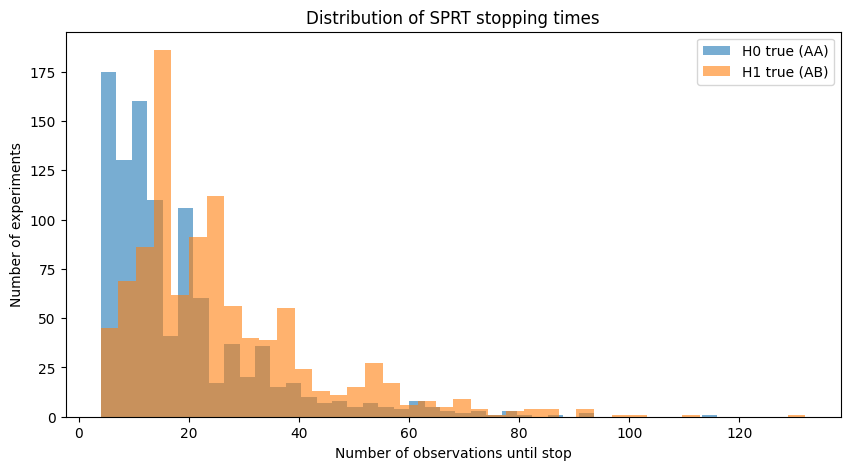

In [8]:
p0 = 0.5
p1 = 0.7

alpha = 0.05
beta = 0.2

upper = np.log((1 - beta) / alpha)
lower = np.log(beta / (1 - alpha))


def stopping_time(p_true, max_steps=500):

    s = 0

    for step in range(1, max_steps + 1):

        x = np.random.binomial(1, p_true)

        p_x_h0 = p0 if x == 1 else (1 - p0)
        p_x_h1 = p1 if x == 1 else (1 - p1)

        s += np.log(p_x_h1 / p_x_h0)

        if s >= upper or s <= lower:
            return step

    return max_steps


n_exp = 1000

times_H0 = [stopping_time(0.5) for _ in range(n_exp)]
times_H1 = [stopping_time(0.7) for _ in range(n_exp)]

plt.figure(figsize=(10, 5))

plt.hist(times_H0, bins=40, alpha=0.6, label="H0 true (AA)")
plt.hist(times_H1, bins=40, alpha=0.6, label="H1 true (AB)")

plt.xlabel("Number of observations until stop")
plt.ylabel("Number of experiments")
plt.title("Distribution of SPRT stopping times")

plt.legend()
plt.show()

Что видим: 

- многие эксперименты **заканчиваются очень рано**
- при наличии эффекта ($H_1$) тест часто останавливается быстрее
- дольше всего идут **пограничные случаи**, где данных недостаточно, чтобы уверенно выбрать гипотезу

Это ключевое свойство sequential testing:

> тест автоматически использует **меньше данных**, когда эффект очевиден.

# Итог

- **Когда применять**: когда нужно анализировать эксперимент по мере накопления данных и иметь возможность **остановить тест раньше**, не нарушая контроль ошибок. На практике чаще используют **mSPRT**, потому что в реальных A/B-тестах мы заранее не знаем точный размер эффекта.

- **Идея метода**: по мере поступления данных накапливается статистика, которая показывает, насколько текущие наблюдения больше поддерживают наличие эффекта, чем его отсутствие.

- **Как принимается решение**: после каждого обновления данных статистика сравнивается с заранее выбранной границей.  
  Если доказательств достаточно — отклоняем нулевую гипотезу.  
  Если нет — продолжаем эксперимент и собираем больше данных.

- **Как применять в A/B-тестах**: выбираем модель для метрики (например, разницу средних для ARPU), считаем статистику на текущих данных и **обновляем её после каждого батча пользователей**.

- **Главное преимущество**: эксперимент **может завершиться раньше**, если эффект достаточно большой или если становится понятно, что сильного эффекта нет. При этом можно **смотреть результаты в любой момент времени**, не увеличивая вероятность ошибки первого рода.